In [2]:
import os
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from goose3 import Goose

/home/germano/Documentos/Automação Completa com Python/venv/lib/python3.10/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/germano/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package punkt to /home/germano/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/germano/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
g = Goose()
url = "https://exame.com/negocios/ifood-lanca-programa-para-entregadores-financiarem-casa-propria-saiba-como-funciona/"
artigo = g.extract(url)

In [4]:
artigo.publish_date

'2026-08-25T17:38:47.000Z'

In [5]:
artigo.title

'iFood lança programa para entregadores financiarem casa própria; saiba como funciona'

In [6]:
artigo.meta_description

'Iniciativa Entregador na Rota da Casa Própria se dá por meio de parcerias da empresa com construtoras e com a Caixa'

In [7]:
artigo.links

['https://exame.com/mercado-imobiliario/receita-de-mrv-sera-positiva-calcula-cfo-apos-resultado-da-previa-operacional/',
 'https://exame.com/invest/mercados/tenda-lucra-meio-milhao-em-2025-e-reve-area-de-casas-industrializadas/',
 'https://exame.com/mercado-imobiliario/quais-sao-os-documentos-necessarios-para-comprar-um-imovel/',
 'https://exame.com/mercado-imobiliario/descubra-o-score-de-credito-ideal-para-financiar-seu-imovel/',
 'https://exame.com/mercado-imobiliario/essa-cidade-esta-cada-vez-mais-proxima-de-uma-bolha-imobiliaria-e-nao-fica-no-brasil/',
 'https://exame.com/invest/minhas-financas/leilao-da-caixa-oferece-mais-de-mil-imoveis-com-ate-52-de-desconto-saiba-como-participar/',
 'https://exame.com/marketing/apos-keeta-ifood-lanca-mochila-especial-e-usa-algoritmo-para-reduzir-falhas-no-delivery/']

In [8]:
artigo.cleaned_text

'O serviço de entregas iFood anunciou nesta terça-feira, 25, um programa de apoio imobiliário para seus entregadores parceiros da categoria Super Diamante.\n\nA iniciativa Entregador na Rota da Casa Própria se dá por meio de parcerias da empresa com construtoras e com a Caixa Econômica Federal, permitindo o acesso facilitado ao financiamento de um imóvel.\n\nO iFood, portanto, não fará as vendas dos imóveis, o programa funciona para integrar os entregadores e o setor imobiliário.\n\nNeste primeiro momento, o mecanismo é apenas disponibilizado a entregadores que tenham permanecido na categoria Super Diamante por 12 meses consecutivos e atuem na cidade de São Paulo. A participação é voluntária e gratuita, mas não garante a aprovação do financiamento nem a compra de um imóvel.\n\nA iniciativa reúne três construtoras parceiras — MRV, Direcional e Tenda —, que oferecem empreendimentos e condições comerciais específicas aos participante.\n\nO entregador interessado deve acessar a página da i

In [9]:
word_tokens = word_tokenize(artigo.cleaned_text)
word_tokens

['O',
 'serviço',
 'de',
 'entregas',
 'iFood',
 'anunciou',
 'nesta',
 'terça-feira',
 ',',
 '25',
 ',',
 'um',
 'programa',
 'de',
 'apoio',
 'imobiliário',
 'para',
 'seus',
 'entregadores',
 'parceiros',
 'da',
 'categoria',
 'Super',
 'Diamante',
 '.',
 'A',
 'iniciativa',
 'Entregador',
 'na',
 'Rota',
 'da',
 'Casa',
 'Própria',
 'se',
 'dá',
 'por',
 'meio',
 'de',
 'parcerias',
 'da',
 'empresa',
 'com',
 'construtoras',
 'e',
 'com',
 'a',
 'Caixa',
 'Econômica',
 'Federal',
 ',',
 'permitindo',
 'o',
 'acesso',
 'facilitado',
 'ao',
 'financiamento',
 'de',
 'um',
 'imóvel',
 '.',
 'O',
 'iFood',
 ',',
 'portanto',
 ',',
 'não',
 'fará',
 'as',
 'vendas',
 'dos',
 'imóveis',
 ',',
 'o',
 'programa',
 'funciona',
 'para',
 'integrar',
 'os',
 'entregadores',
 'e',
 'o',
 'setor',
 'imobiliário',
 '.',
 'Neste',
 'primeiro',
 'momento',
 ',',
 'o',
 'mecanismo',
 'é',
 'apenas',
 'disponibilizado',
 'a',
 'entregadores',
 'que',
 'tenham',
 'permanecido',
 'na',
 'categoria',


In [10]:
len(word_tokens)

1032

In [11]:
portuguese_stops = set(stopwords.words('portuguese'))

In [ ]:
palavras = [palavra for palavra in word_tokens if palavra.lower() not in portuguese_stops]
palavras

['O',
 'serviço',
 'entregas',
 'iFood',
 'anunciou',
 'nesta',
 'terça-feira',
 ',',
 '25',
 ',',
 'programa',
 'apoio',
 'imobiliário',
 'entregadores',
 'parceiros',
 'categoria',
 'Super',
 'Diamante',
 '.',
 'A',
 'iniciativa',
 'Entregador',
 'Rota',
 'Casa',
 'Própria',
 'dá',
 'meio',
 'parcerias',
 'empresa',
 'construtoras',
 'Caixa',
 'Econômica',
 'Federal',
 ',',
 'permitindo',
 'acesso',
 'facilitado',
 'financiamento',
 'imóvel',
 '.',
 'O',
 'iFood',
 ',',
 'portanto',
 ',',
 'fará',
 'vendas',
 'imóveis',
 ',',
 'programa',
 'funciona',
 'integrar',
 'entregadores',
 'setor',
 'imobiliário',
 '.',
 'Neste',
 'primeiro',
 'momento',
 ',',
 'mecanismo',
 'apenas',
 'disponibilizado',
 'entregadores',
 'permanecido',
 'categoria',
 'Super',
 'Diamante',
 '12',
 'meses',
 'consecutivos',
 'atuem',
 'cidade',
 'São',
 'Paulo',
 '.',
 'A',
 'participação',
 'voluntária',
 'gratuita',
 ',',
 'garante',
 'aprovação',
 'financiamento',
 'compra',
 'imóvel',
 '.',
 'A',
 'inicia

In [13]:
len(palavras)

706

In [14]:
fdist = FreqDist(palavras)
fdist.most_common(10)

[(',', 60),
 ('.', 45),
 ('O', 14),
 ('programa', 12),
 ('entregador', 11),
 ('A', 10),
 ('Super', 8),
 ('imóvel', 8),
 ('iFood', 7),
 ('entregadores', 7)]

In [15]:
novas_palavras = [palavra for palavra in palavras if palavra.isalnum()]
len(novas_palavras)

587

In [16]:
fdist2 = FreqDist(novas_palavras)
fdist2.most_common(10)

[('O', 14),
 ('programa', 12),
 ('entregador', 11),
 ('A', 10),
 ('Super', 8),
 ('imóvel', 8),
 ('iFood', 7),
 ('entregadores', 7),
 ('financiamento', 7),
 ('meses', 7)]

In [17]:
def plot_cloud(wordcloud):
    plt.figure(figsize=(40,30))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.show()
    

In [18]:
wc = WordCloud(
    width=3000,
    height=2000,
    random_state=1,
    background_color="white",
    colormap="Pastel1",
    collocations=False,
    stopwords=STOPWORDS
)
wc.generate(" ".join(novas_palavras))

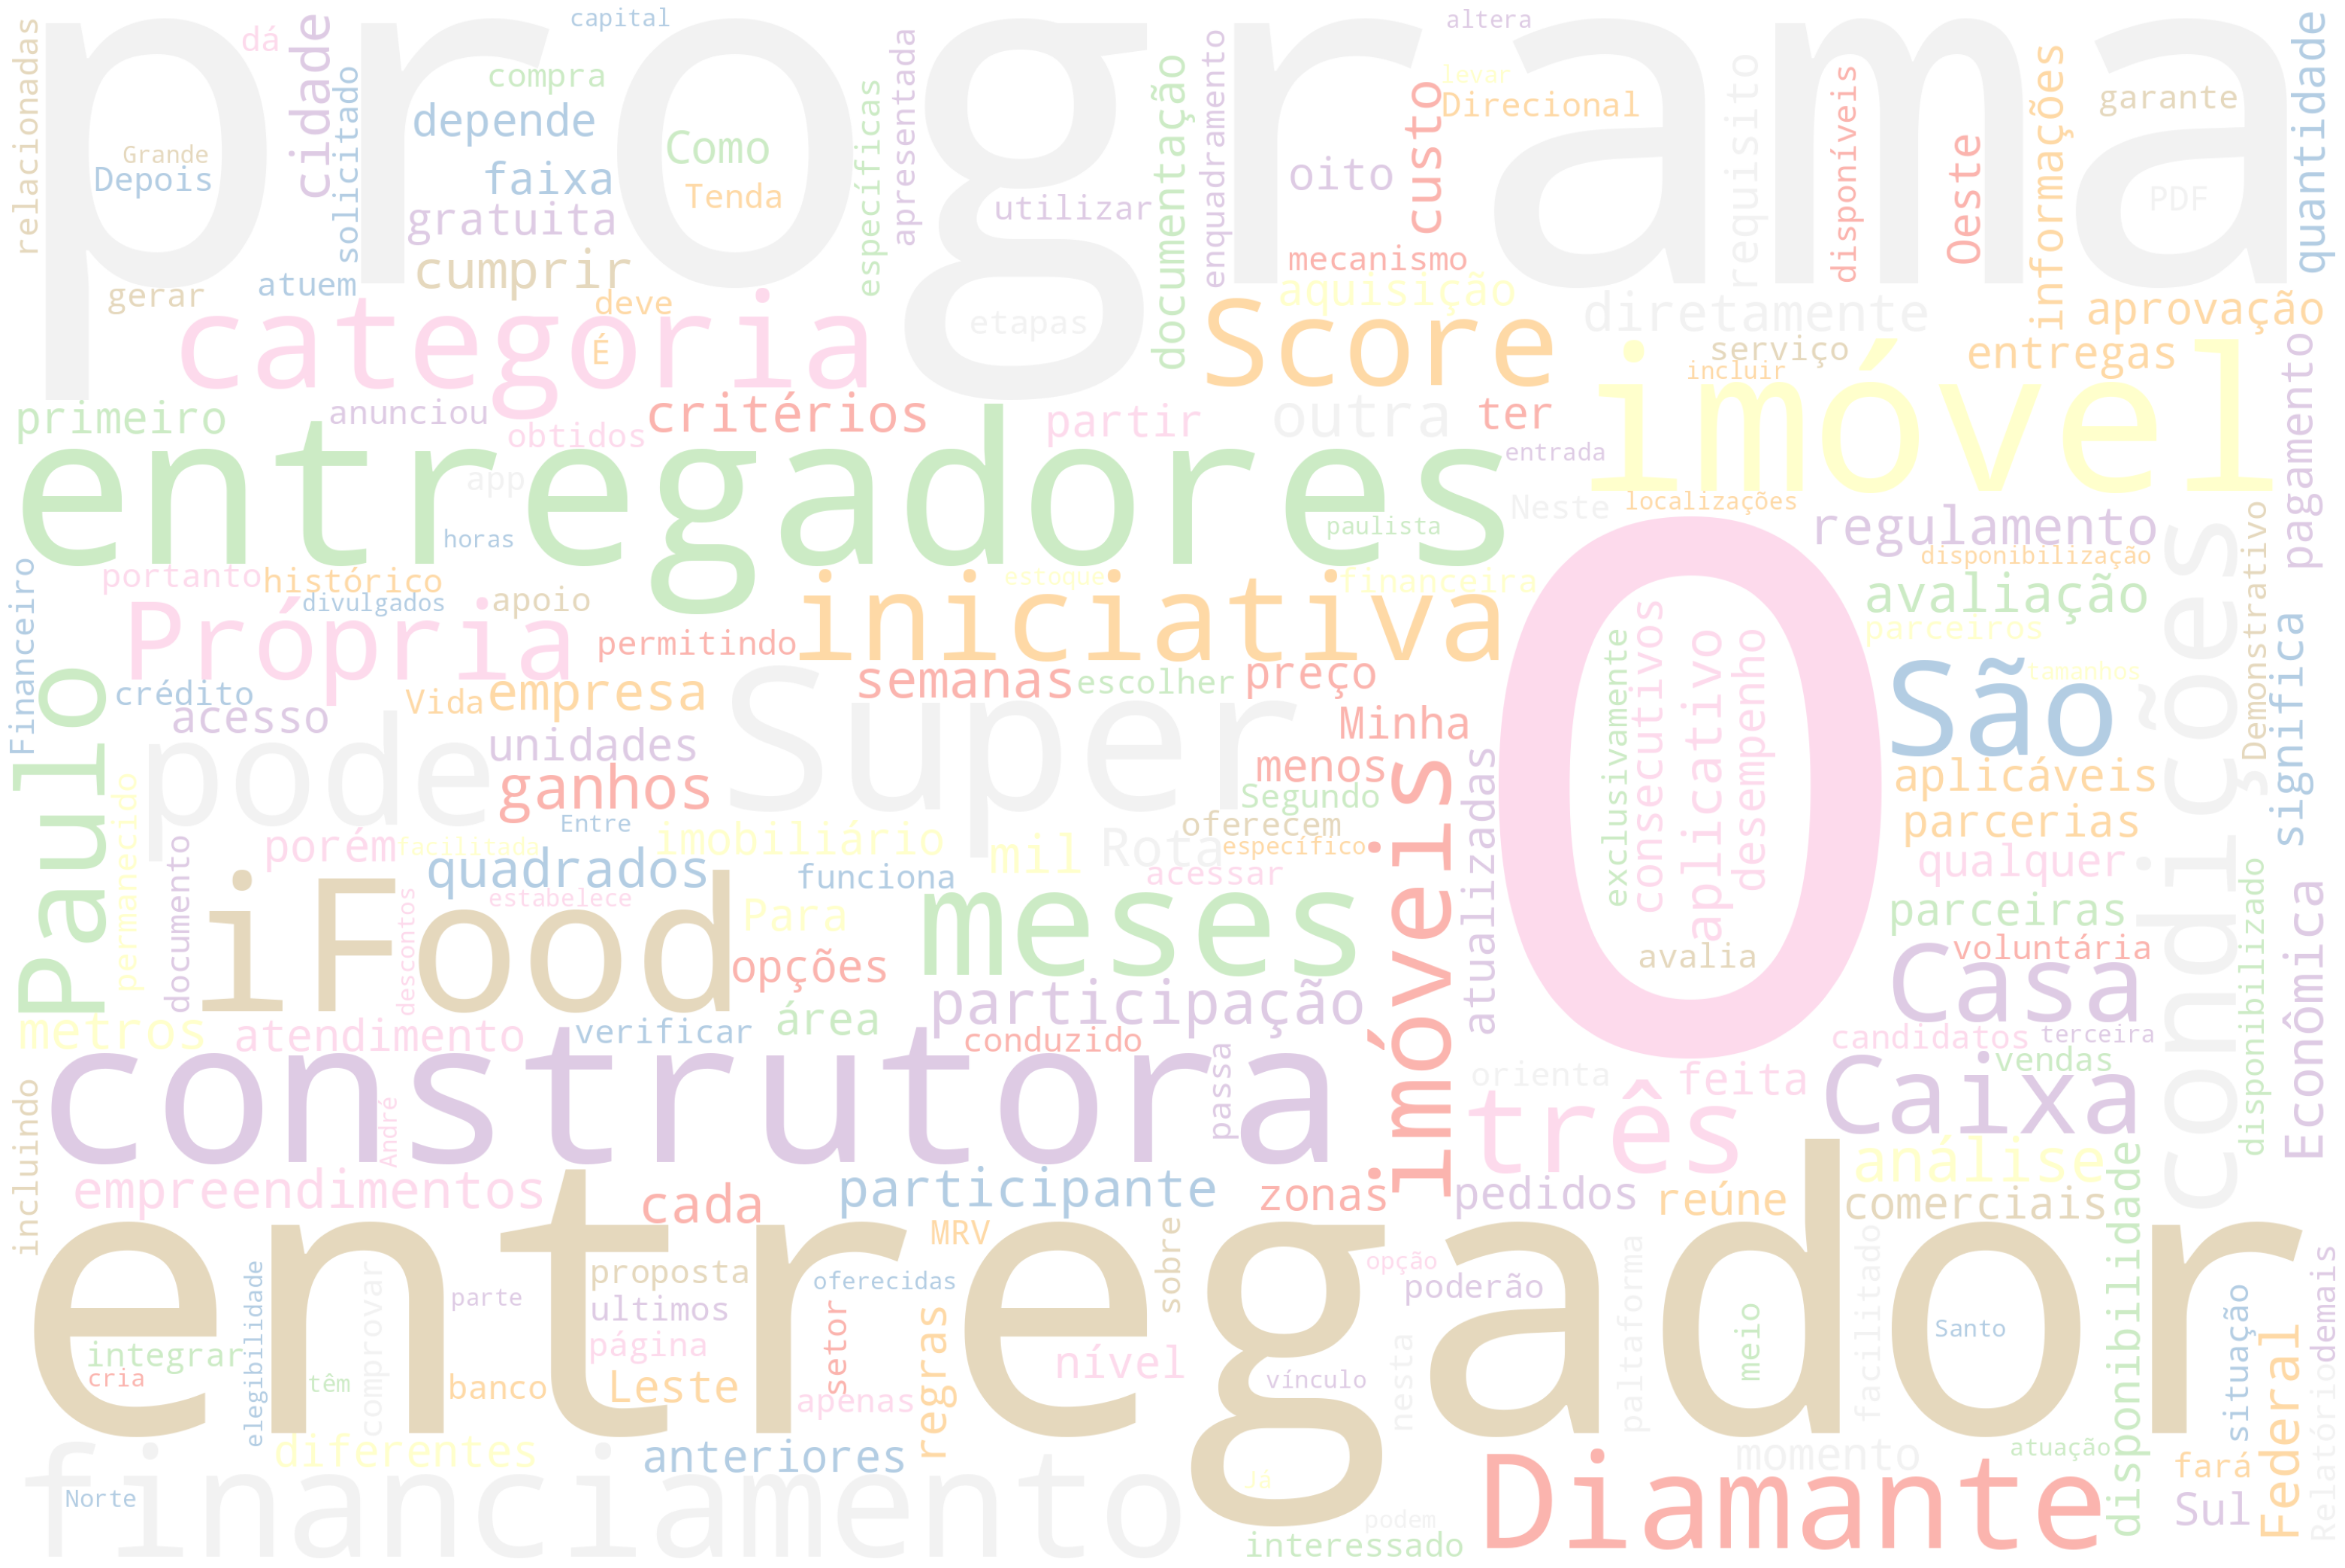

In [19]:
plot_cloud(wc)